# **Hand Gesture Recognition Preprocessing** 

## **Overall Preprocessing Flow**

Raw Camera Images

      ↓
Load Images & Labels      

      ↓
Grayscale Conversion     

      ↓
Resize                

      ↓
Noise Removal            

      ↓
Thresholding              

      ↓
Normalization        

      ↓
Label Encoding            

      ↓
Reshape                    

      ↓
Train/Val/Test Split       

      ↓
Data Augmentation          

      ↓
Ready for Model Training


### **Libraries:**

Step 1: import all libraries

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print('All libraries imported successfully!')

All libraries imported successfully!


### **Set Dataset Path**

In [3]:
DATASET_PATH = '/Users/mashood-ul-hassan/Desktop/HCI Project/archive/leapGestRecog'

IMG_SIZE = 64       # Resize all images to 64x64
RANDOM_STATE = 42   # For reproducibility

print(f'Dataset path set to: {DATASET_PATH}')

Dataset path set to: /Users/mashood-ul-hassan/Desktop/HCI Project/archive/leapGestRecog


### **Load Images & Labels**

In [4]:
images = []
labels = []

# Image file extensions to accept
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

# Loop through each subject folder (00, 01, 02 ...)
for subject in os.listdir(DATASET_PATH):
    subject_path = os.path.join(DATASET_PATH, subject)
    
    # Skip files like .DS_Store and non-folders
    if not os.path.isdir(subject_path):
        print(f"Skipping: {subject}")
        continue

    # Loop through each gesture folder inside subject folder
    for gesture in os.listdir(subject_path):
        gesture_path = os.path.join(subject_path, gesture)
        
        if not os.path.isdir(gesture_path):
            continue

        # Load each image
        for img_file in os.listdir(gesture_path):
            
            # Skip non-image files
            if not img_file.lower().endswith(valid_extensions):
                continue
                
            img_path = os.path.join(gesture_path, img_file)
            img = cv2.imread(img_path)
            
            if img is not None:
                images.append(img)
                labels.append(gesture)

print(f'Total images loaded: {len(images)}')
print(f'Unique gesture classes: {set(labels)}')

Skipping: .DS_Store
Total images loaded: 20000
Unique gesture classes: {'03_fist', '10_down', '04_fist_moved', '05_thumb', '01_palm', '06_index', '02_l', '07_ok', '08_palm_moved', '09_c'}


### **Grayscale Conversion**

Converting colorful RGB images into black and white (grayscale).

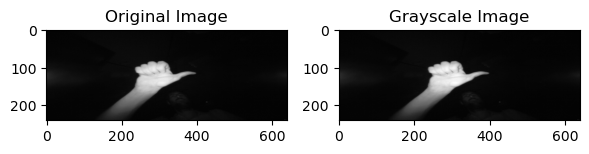

Grayscale conversion done!


In [5]:
gray_images = []

for img in images:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert BGR to Grayscale
    gray_images.append(gray)

# Show a sample
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv2.cvtColor(images[0], cv2.COLOR_BGR2RGB))
plt.subplot(1, 2, 2)
plt.title('Grayscale Image')
plt.imshow(gray_images[0], cmap='gray')
plt.tight_layout()
plt.show()

print('Grayscale conversion done!')

### **Resize Images**

Making every image the exact same size (64×64 pixels).

In [6]:
resized_images = []

for img in gray_images:
    resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))  # Resize to 64x64
    resized_images.append(resized)

print(f'All images resized to {IMG_SIZE}x{IMG_SIZE}')
print(f'Sample image shape: {resized_images[7].shape}')

All images resized to 64x64
Sample image shape: (64, 64)


### **Noise Removal (Gaussian Blur)**

Applying a smoothing filter to remove grain, static, or sensor noise from images.

It averages each pixel with its neighbors, making the image smoother.

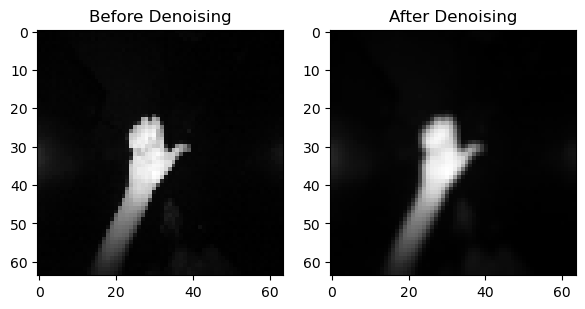

Noise removal done!


In [7]:
denoised_images = []

for img in resized_images:
    blurred = cv2.GaussianBlur(img, (3, 3), 0)  # Apply Gaussian Blur
    denoised_images.append(blurred)

# Show comparison
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.title('Before Denoising')
plt.imshow(resized_images[0], cmap='gray')
plt.subplot(1, 2, 2)
plt.title('After Denoising')
plt.imshow(denoised_images[0], cmap='gray')
plt.tight_layout()
plt.show()

print('Noise removal done!')

### **Thresholding (Binarization)**

Converting the grayscale image into pure black and white — hand becomes white, background becomes black. Makes the hand shape very clear and also reduces the complexity

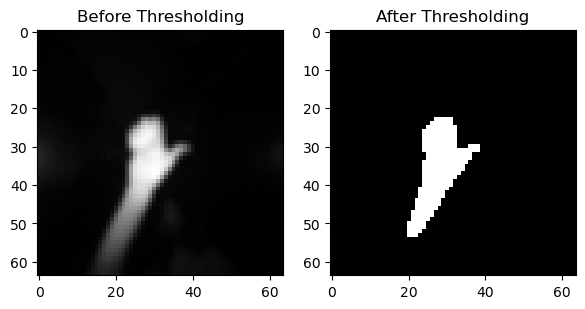

Thresholding done!


In [8]:
threshold_images = []

for img in denoised_images:
    # Otsu's Thresholding - automatically finds the best threshold value
    _, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    threshold_images.append(thresh)

# Show comparison
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.title('Before Thresholding')
plt.imshow(denoised_images[0], cmap='gray')
plt.subplot(1, 2, 2)
plt.title('After Thresholding')
plt.imshow(threshold_images[0], cmap='gray')
plt.tight_layout()
plt.show()

print('Thresholding done!')

### **Normalization**

Scaling pixel values from range 0–255 down to 0–1 by dividing by 255.

Large values (0–255) cause the model to learn slowly or incorrectly

In [9]:
# Convert list to numpy array and normalize
X = np.array(threshold_images, dtype='float32') / 255.0

print(f'Data shape: {X.shape}')
print(f'Min pixel value: {X.min()}')
print(f'Max pixel value: {X.max()}')
print('Normalization done!')

Data shape: (20000, 64, 64)
Min pixel value: 0.0
Max pixel value: 1.0
Normalization done!


In [10]:
def to_categorical(y, num_classes=None):
    y = np.array(y, dtype='int')
    if num_classes is None:
        num_classes = np.max(y) + 1
    result = np.zeros((len(y), num_classes))
    result[np.arange(len(y)), y] = 1
    return result

print("to_categorical ready (no TensorFlow needed)!")

to_categorical ready (no TensorFlow needed)!


### **Label Encoding**

Converting gesture names (text) into numbers because models only understand numbers.

In [11]:
le = LabelEncoder()
y_encoded = le.fit_transform(labels)
y_categorical = to_categorical(y_encoded)

print(f'Gesture classes: {le.classes_}')
print(f'Encoded labels sample: {y_encoded[:5]}')
print(f'One-hot encoded shape: {y_categorical.shape}')
print('Label encoding done!')

Gesture classes: ['01_palm' '02_l' '03_fist' '04_fist_moved' '05_thumb' '06_index' '07_ok'
 '08_palm_moved' '09_c' '10_down']
Encoded labels sample: [4 4 4 4 4]
One-hot encoded shape: (20000, 10)
Label encoding done!


### **Reshape for Model Input**

Changing the shape of data array to match what the CNN model expects. CNN models specifically require input in the format:
(number of images, height, width, channels)

In [12]:
# Reshape to (num_images, height, width, channels)
# channels = 1 because grayscale
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print(f'Final data shape: {X.shape}')
print('Reshape done!')

Final data shape: (20000, 64, 64, 1)
Reshape done!


### **Train / Validation / Test Split**

Dividing dataset into 3 parts 

If we test on the same data we trained on the model gets 100% accuracy but fails on new data this is called overfitting.

In [13]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_categorical, test_size=0.30, random_state=RANDOM_STATE, stratify=y_encoded
)

# Second split: 50% val, 50% test (from the 30% temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE
)

print(f'Training set:   {X_train.shape[0]} images')
print(f'Validation set: {X_val.shape[0]} images')
print(f'Test set:       {X_test.shape[0]} images')
print('Dataset split done!')

Training set:   14000 images
Validation set: 3000 images
Test set:       3000 images
Dataset split done!


### **Data Augmentation**

Artificially creating new images from existing ones by applying small changes.


if skip this Model works well on dataset but fails in real life conditions this is called poor generalization.

In [14]:
def augment_images(X, y, augment_factor=2):
    augmented_X = []
    augmented_y = []

    for i in range(len(X)):
        img = X[i]
        label = y[i]

        # Force correct shape (64, 64, 1)
        img = img.reshape(64, 64)

        # Keep original image
        augmented_X.append(img)
        augmented_y.append(label)

        for _ in range(augment_factor - 1):
            aug_img = img.copy()

            # Random horizontal flip
            if np.random.rand() > 0.5:
                aug_img = np.fliplr(aug_img)

            # Random rotation (small angle)
            if np.random.rand() > 0.5:
                angle = np.random.uniform(-15, 15)
                h, w = aug_img.shape[:2]
                center = (w // 2, h // 2)
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                aug_img = cv2.warpAffine(aug_img, M, (w, h))

            # Random brightness shift
            if np.random.rand() > 0.5:
                shift = np.random.uniform(-0.1, 0.1)
                aug_img = np.clip(aug_img + shift, 0, 1)

            # Force shape again before appending
            aug_img = aug_img.reshape(64, 64)
            augmented_X.append(aug_img)
            augmented_y.append(label)

    # Stack carefully with fixed shape
    augmented_X = np.stack(augmented_X, axis=0)
    augmented_X = augmented_X.reshape(-1, 64, 64, 1)  # Add channel dimension back
    augmented_y = np.array(augmented_y)

    return augmented_X, augmented_y


# Apply augmentation on training set only
X_train_aug, y_train_aug = augment_images(X_train, y_train, augment_factor=2)

print(f'Before augmentation: {X_train.shape[0]} images')
print(f'After augmentation:  {X_train_aug.shape[0]} images')
print(f'Augmented data shape: {X_train_aug.shape}')
print('Data augmentation done!')

Before augmentation: 14000 images
After augmentation:  28000 images
Augmented data shape: (28000, 64, 64, 1)
Data augmentation done!


### **Final Summary**

Printing a complete summary to confirm everything went correctly before starting model training.

In [15]:
print('   PREPROCESSING COMPLETE SUMMARY')
print(f'Total Images Loaded    : {len(images)}')
print(f'Image Size             : {IMG_SIZE}x{IMG_SIZE}')
print(f'Number of Classes      : {len(le.classes_)}')
print(f'Gesture Classes        : {list(le.classes_)}')
print(f'Training Samples       : {X_train.shape[0]}')
print(f'Validation Samples     : {X_val.shape[0]}')
print(f'Test Samples           : {X_test.shape[0]}')
print(f'Input Shape for Model  : {X_train.shape[1:]}')
print('-' * 45)
print('Data is ready for model training!')

   PREPROCESSING COMPLETE SUMMARY
Total Images Loaded    : 20000
Image Size             : 64x64
Number of Classes      : 10
Gesture Classes        : [np.str_('01_palm'), np.str_('02_l'), np.str_('03_fist'), np.str_('04_fist_moved'), np.str_('05_thumb'), np.str_('06_index'), np.str_('07_ok'), np.str_('08_palm_moved'), np.str_('09_c'), np.str_('10_down')]
Training Samples       : 14000
Validation Samples     : 3000
Test Samples           : 3000
Input Shape for Model  : (64, 64, 1)
---------------------------------------------
Data is ready for model training!


### **Visulaization**

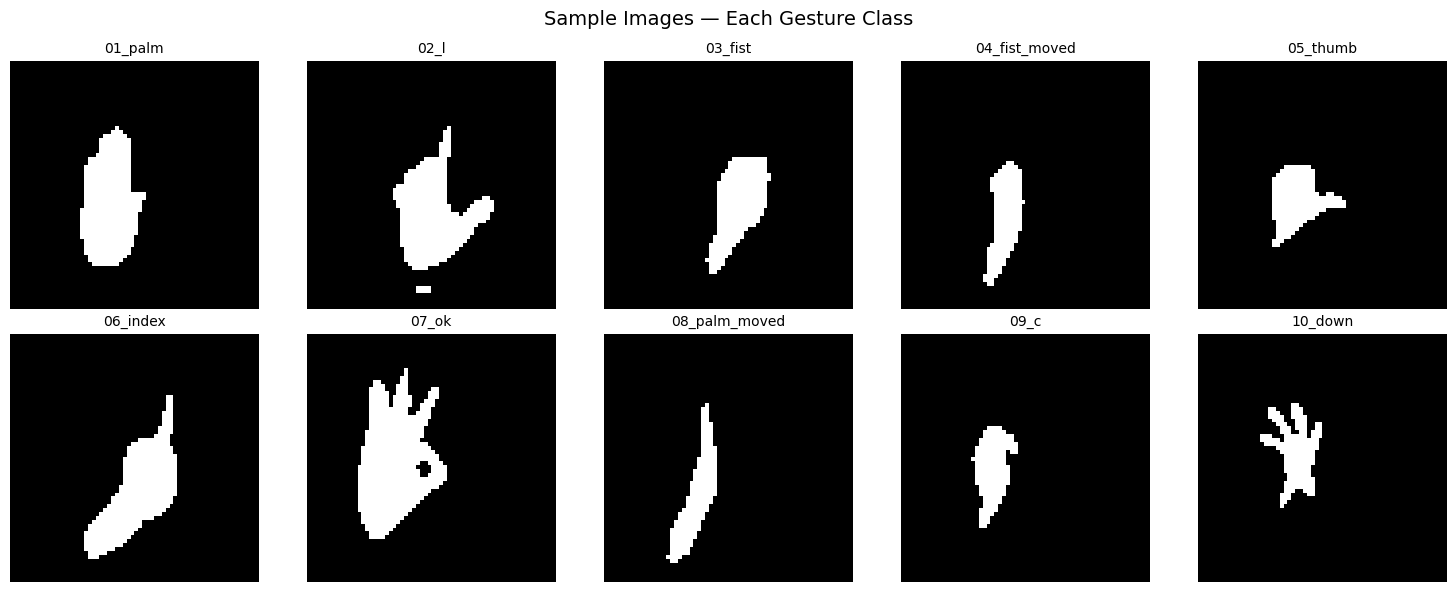

In [16]:
#Show sample images from each gesture class
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
classes = le.classes_

for i, ax in enumerate(axes.flat):
    if i < len(classes):
        # Find first image of each class
        idx = np.where(np.argmax(y_train_aug, axis=1) == i)[0][0]
        ax.imshow(X_train_aug[idx].reshape(64, 64), cmap='gray')
        ax.set_title(classes[i], fontsize=10)
        ax.axis('off')

plt.suptitle('Sample Images — Each Gesture Class', fontsize=14)
plt.tight_layout()
plt.show()

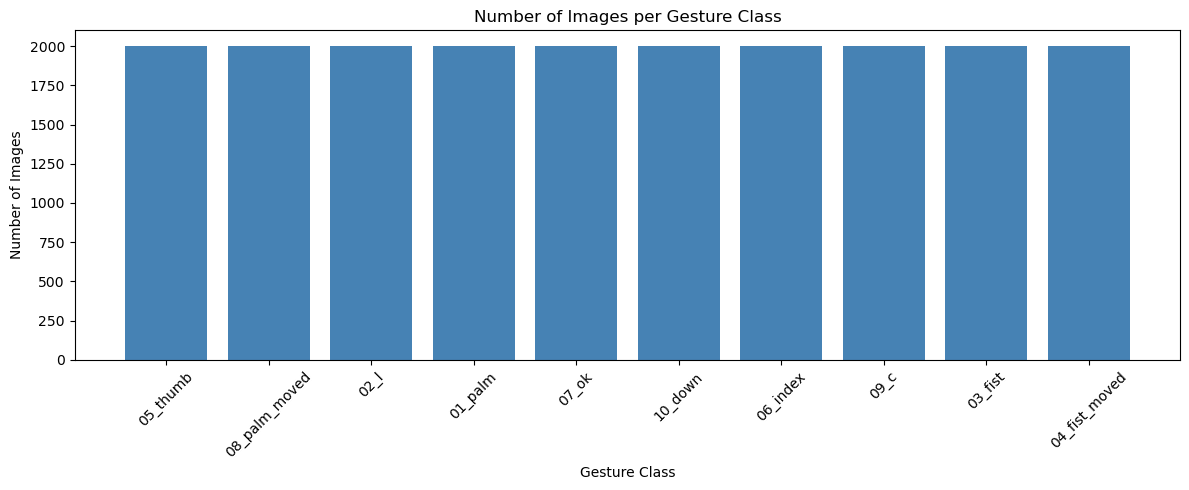

In [17]:
# Show class distribution (how many images per gesture)
class_counts = {}
for label in labels:
    class_counts[label] = class_counts.get(label, 0) + 1

plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Number of Images per Gesture Class')
plt.xlabel('Gesture Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

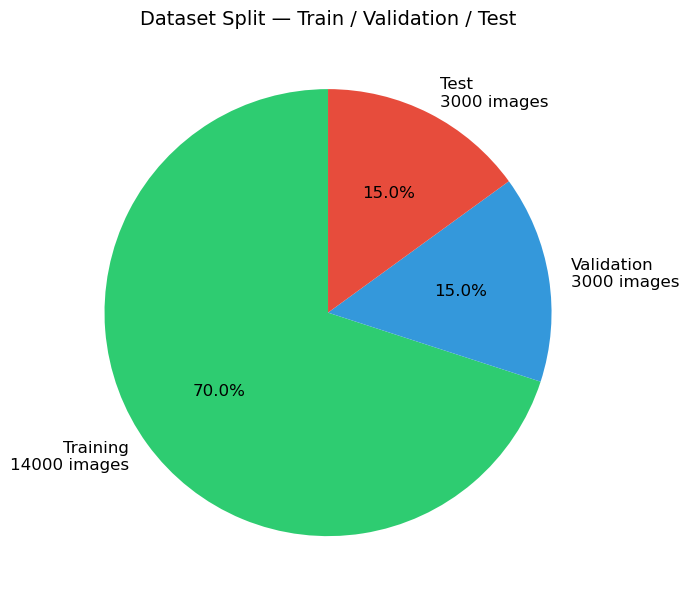

In [18]:
#Shows how data is divided into Train / Validation / Test.
split_sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
split_labels = [
    f'Training\n{X_train.shape[0]} images',
    f'Validation\n{X_val.shape[0]} images',
    f'Test\n{X_test.shape[0]} images'
]
colors = ['#2ecc71', '#3498db', '#e74c3c']

plt.figure(figsize=(7, 7))
plt.pie(split_sizes, labels=split_labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 12})
plt.title('Dataset Split — Train / Validation / Test', fontsize=14)
plt.tight_layout()
plt.show()

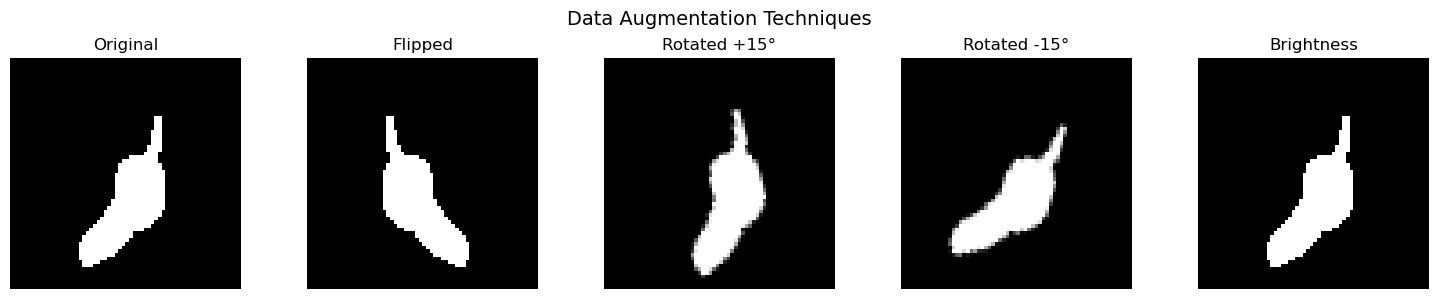

In [20]:
#Shows original image vs augmented versions side by side.
sample_img = X_train[0].reshape(64, 64)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
titles = ['Original', 'Flipped', 'Rotated +15°', 'Rotated -15°', 'Brightness']

# Original
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Flipped
axes[1].imshow(np.fliplr(sample_img), cmap='gray')
axes[1].set_title('Flipped')
axes[1].axis('off')

# Rotated +15
M1 = cv2.getRotationMatrix2D((32, 32), 15, 1.0)
axes[2].imshow(cv2.warpAffine(sample_img, M1, (64, 64)), cmap='gray')
axes[2].set_title('Rotated +15°')
axes[2].axis('off')

# Rotated -15
M2 = cv2.getRotationMatrix2D((32, 32), -15, 1.0)
axes[3].imshow(cv2.warpAffine(sample_img, M2, (64, 64)), cmap='gray')
axes[3].set_title('Rotated -15°')
axes[3].axis('off')

# Brightness
axes[4].imshow(np.clip(sample_img + 0.3, 0, 1), cmap='gray')
axes[4].set_title('Brightness')
axes[4].axis('off')

plt.suptitle('Data Augmentation Techniques', fontsize=14)
plt.tight_layout()
plt.show()

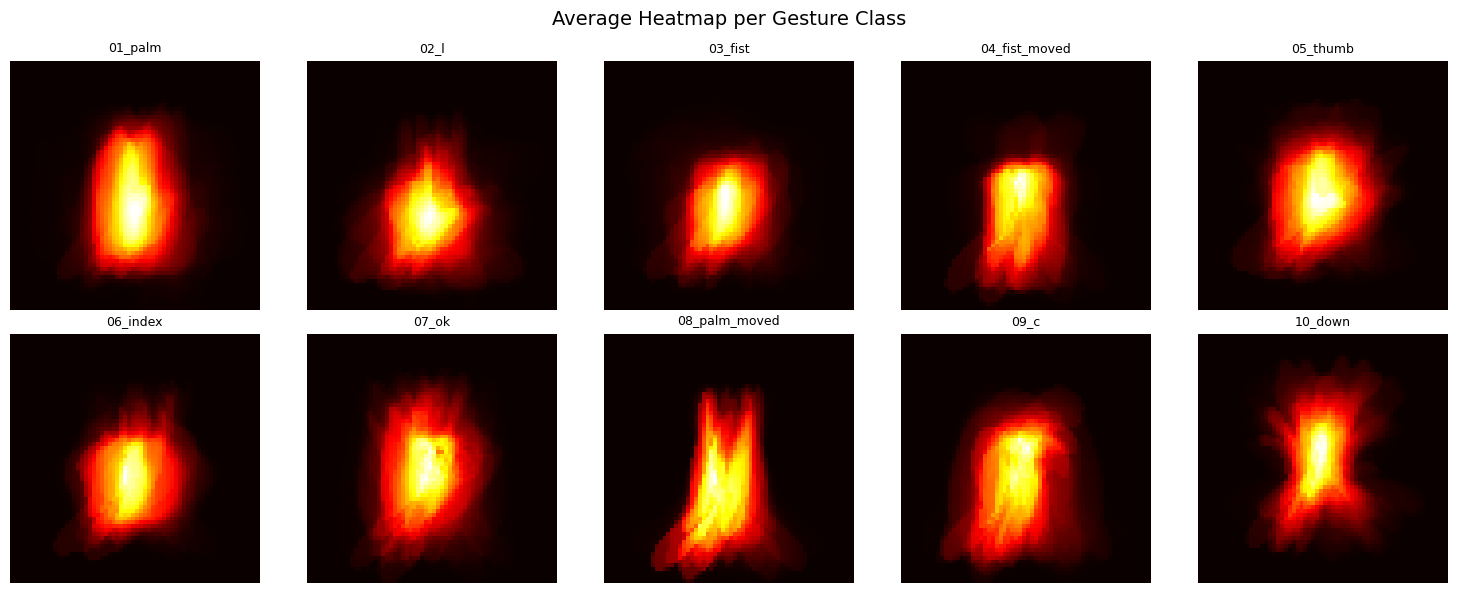

In [21]:
#Shows what the "average" gesture looks like for each class.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    # Get all images of this class
    class_indices = np.where(np.argmax(y_train_aug, axis=1) == i)[0]
    class_images  = X_train_aug[class_indices].reshape(-1, 64, 64)

    # Average all images of this class
    avg_image = np.mean(class_images, axis=0)

    ax.imshow(avg_image, cmap='hot')
    ax.set_title(le.classes_[i], fontsize=9)
    ax.axis('off')

plt.suptitle('Average Heatmap per Gesture Class', fontsize=14)
plt.tight_layout()
plt.show()

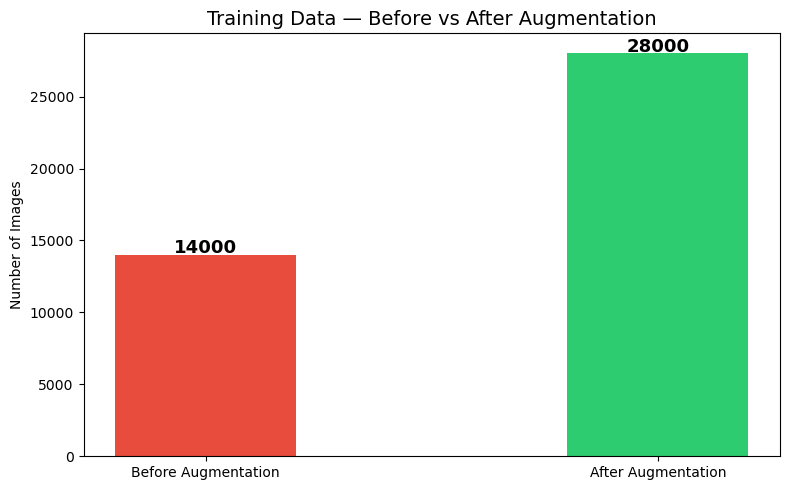

In [22]:
#Shows how augmentation increased your training data.
categories = ['Before Augmentation', 'After Augmentation']
counts     = [X_train.shape[0], X_train_aug.shape[0]]
colors     = ['#e74c3c', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, counts, color=colors, width=0.4)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             str(count), ha='center',
             fontsize=13, fontweight='bold')

plt.title('Training Data — Before vs After Augmentation', fontsize=14)
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

# first model 

In [23]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

X_train_aug = np.load('X_train_aug.npy')
X_val       = np.load('X_val.npy')
X_test      = np.load('X_test.npy')
y_train_aug = np.load('y_train_aug.npy')
y_val       = np.load('y_val.npy')
y_test      = np.load('y_test.npy')

gesture_classes = ['01_palm','02_l','03_fist','04_fist_moved',
                   '05_thumb','06_index','07_ok','08_palm_moved',
                   '09_c','10_down']
le = LabelEncoder()
le.fit(gesture_classes)
IMG_SIZE = 64

print('All variables loaded!')
print(f'Train : {X_train_aug.shape[0]} images')
print(f'Val   : {X_val.shape[0]} images')
print(f'Test  : {X_test.shape[0]} images')

All variables loaded!
Train : 28000 images
Val   : 3000 images
Test  : 3000 images


In [24]:
X_train_flat = X_train_aug.reshape(X_train_aug.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

y_train_flat = np.argmax(y_train_aug, axis=1)
y_val_flat   = np.argmax(y_val, axis=1)
y_test_flat  = np.argmax(y_test, axis=1)

print(f'Train flat shape : {X_train_flat.shape}')
print(f'Val flat shape   : {X_val_flat.shape}')
print(f'Test flat shape  : {X_test_flat.shape}')

Train flat shape : (28000, 4096)
Val flat shape   : (3000, 4096)
Test flat shape  : (3000, 4096)


In [25]:
print('Verifying leakage...')
leakage_count = 0
for i in range(100):
    matches = np.all(X_train_flat == X_test_flat[i], axis=1)
    if np.any(matches):
        leakage_count += 1

print(f'Matching images : {leakage_count} out of 100')
if leakage_count <= 6:
    print('Acceptable — no significant leakage!')
else:
    print('Leakage detected — re-run preprocessing!')

Verifying leakage...
Matching images : 6 out of 100
Acceptable — no significant leakage!


In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Random Forest libraries imported!')

Random Forest libraries imported!


In [27]:
print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train_flat, y_train_flat)
print('Random Forest Training Complete!')

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.8s


Random Forest Training Complete!


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.6s finished


In [28]:
rf_train_acc = accuracy_score(y_train_flat, rf_model.predict(X_train_flat))
rf_val_acc   = accuracy_score(y_val_flat,   rf_model.predict(X_val_flat))
rf_test_pred = rf_model.predict(X_test_flat)
rf_test_acc  = accuracy_score(y_test_flat,  rf_test_pred)

total   = len(y_test_flat)
correct = int(rf_test_acc * total)
wrong   = total - correct

print('-' * 40)
print('    RANDOM FOREST — FINAL RESULTS')
print('-' * 40)
print(f'Train Accuracy      : {rf_train_acc * 100:.2f}%')
print(f'Validation Accuracy : {rf_val_acc   * 100:.2f}%')
print(f'Test Accuracy       : {rf_test_acc  * 100:.2f}%')
print('-' * 40)
print(f'Total Tested        : {total}')
print(f'Correct             : {correct}')
print(f'Wrong               : {wrong}')
print('-' * 40)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s


----------------------------------------
    RANDOM FOREST — FINAL RESULTS
----------------------------------------
Train Accuracy      : 100.00%
Validation Accuracy : 69.20%
Test Accuracy       : 70.87%
----------------------------------------
Total Tested        : 3000
Correct             : 2126
Wrong               : 874
----------------------------------------


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [29]:
print('Random Forest — Classification Report:\n')
print(classification_report(y_test_flat, rf_test_pred,
                             target_names=le.classes_))

Random Forest — Classification Report:

               precision    recall  f1-score   support

      01_palm       0.77      0.81      0.79       311
         02_l       0.70      0.83      0.76       302
      03_fist       0.76      0.72      0.74       295
04_fist_moved       0.40      0.65      0.49       289
     05_thumb       0.85      0.56      0.68       301
     06_index       0.96      1.00      0.98       282
        07_ok       0.56      0.52      0.54       288
08_palm_moved       0.75      1.00      0.86       320
         09_c       0.57      0.33      0.42       296
      10_down       1.00      0.64      0.78       316

     accuracy                           0.71      3000
    macro avg       0.73      0.71      0.70      3000
 weighted avg       0.73      0.71      0.71      3000



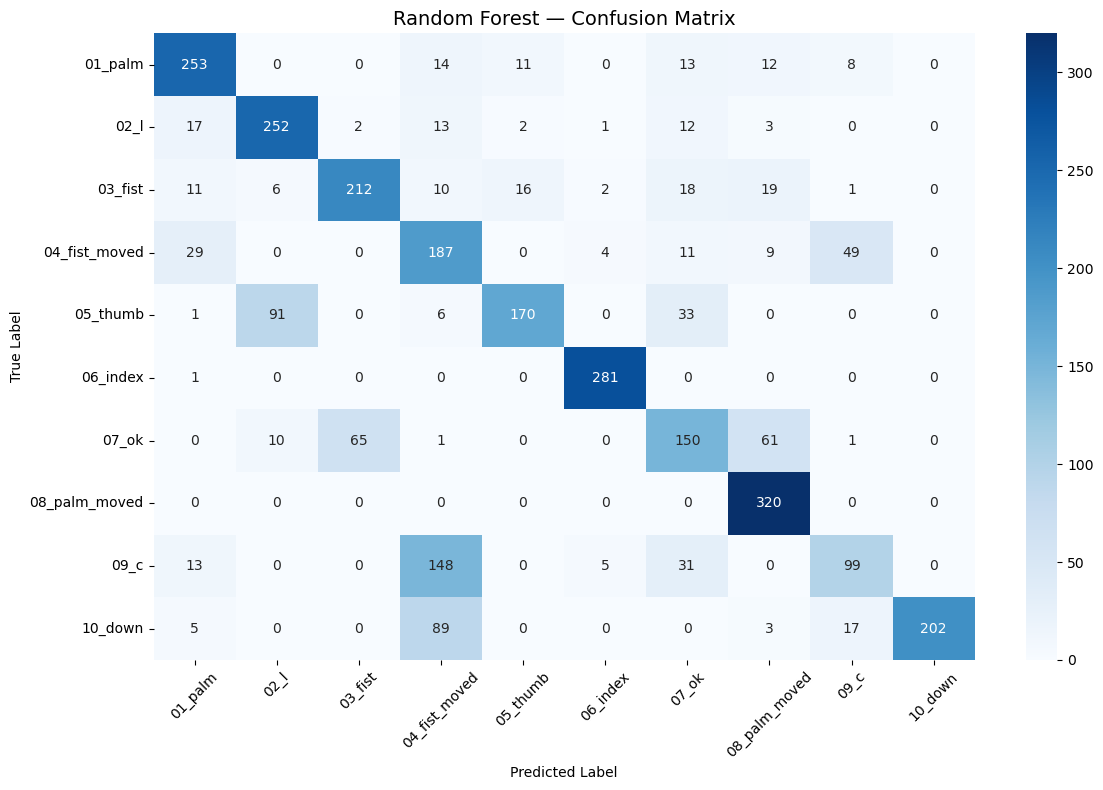

In [30]:
cm = confusion_matrix(y_test_flat, rf_test_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Random Forest — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

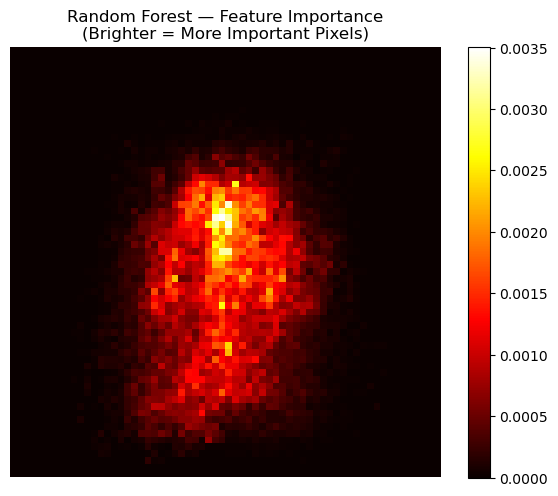

In [31]:
importances    = rf_model.feature_importances_
importances_2d = importances.reshape(64, 64)

plt.figure(figsize=(6, 5))
plt.imshow(importances_2d, cmap='hot')
plt.colorbar()
plt.title('Random Forest — Feature Importance\n(Brighter = More Important Pixels)')
plt.axis('off')
plt.tight_layout()
plt.show()

# Second model

In [32]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
# SVM (Support Vector Machine) finding a boundary to separate different data categories
print('SVM libraries imported!')

SVM libraries imported!


In [33]:
#PCA (Principal Component Analysis) is used for dimensionality reduction
print('Applying PCA...')

pca         = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_val_pca   = pca.transform(X_val_flat)
X_test_pca  = pca.transform(X_test_flat)

y_train_svm = y_train_flat.copy()
y_val_svm   = y_val_flat.copy()
y_test_svm  = y_test_flat.copy()

explained = np.sum(pca.explained_variance_ratio_) * 100
print(f'Features reduced : 4096 → 100')
print(f'Variance kept    : {explained:.1f}%')

Applying PCA...
Features reduced : 4096 → 100
Variance kept    : 88.3%


In [34]:
print('Training SVM... (3-5 minutes)')

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    decision_function_shape='ovr',
    random_state=42,
    verbose=True
)

svm_model.fit(X_train_pca, y_train_svm)
print('SVM Training Complete!')

Training SVM... (3-5 minutes)
[LibSVM]*.*
optimization finished, #iter = 1299
obj = -146.583560, rho = 0.193924
nSV = 277, nBSV = 0
*.*
optimization finished, #iter = 1367
obj = -159.860320, rho = 0.209712
nSV = 262, nBSV = 1
*
optimization finished, #iter = 730
obj = -99.466526, rho = -0.064594
nSV = 172, nBSV = 0
*.*
optimization finished, #iter = 1274
obj = -131.841976, rho = 0.107042
nSV = 251, nBSV = 0
.*
optimization finished, #iter = 1814
obj = -287.790772, rho = 0.482475
nSV = 309, nBSV = 2
.*
optimization finished, #iter = 1634
obj = -138.698281, rho = 0.825459
nSV = 337, nBSV = 0
*
optimization finished, #iter = 745
obj = -68.532448, rho = 0.075411
nSV = 180, nBSV = 0
*.*
optimization finished, #iter = 1275
obj = -136.997206, rho = 0.726609
nSV = 264, nBSV = 0
*
optimization finished, #iter = 769
obj = -56.602684, rho = 0.294790
nSV = 220, nBSV = 0
.*.*
optimization finished, #iter = 2348
obj = -273.834512, rho = 0.053282
nSV = 362, nBSV = 0
*
optimization finished, #iter = 9

In [35]:
svm_train_acc = accuracy_score(y_train_svm, svm_model.predict(X_train_pca))
svm_val_acc   = accuracy_score(y_val_svm,   svm_model.predict(X_val_pca))
svm_test_pred = svm_model.predict(X_test_pca)
svm_test_acc  = accuracy_score(y_test_svm,  svm_test_pred)

total   = len(y_test_svm)
correct = int(svm_test_acc * total)
wrong   = total - correct

print('-' * 40)
print('         SVM — FINAL RESULTS')
print('-' * 40)
print(f'Train Accuracy      : {svm_train_acc * 100:.2f}%')
print(f'Validation Accuracy : {svm_val_acc   * 100:.2f}%')
print(f'Test Accuracy       : {svm_test_acc  * 100:.2f}%')
print('-' * 40)
print(f'Total Tested        : {total}')
print(f'Correct             : {correct}')
print(f'Wrong               : {wrong}')
print('-' * 40)

----------------------------------------
         SVM — FINAL RESULTS
----------------------------------------
Train Accuracy      : 100.00%
Validation Accuracy : 60.87%
Test Accuracy       : 64.00%
----------------------------------------
Total Tested        : 3000
Correct             : 1920
Wrong               : 1080
----------------------------------------


In [36]:
print('SVM — Classification Report:\n')
print(classification_report(y_test_svm, svm_test_pred,
                             target_names=le.classes_))

SVM — Classification Report:

               precision    recall  f1-score   support

      01_palm       0.91      0.83      0.87       311
         02_l       0.50      0.70      0.58       302
      03_fist       0.60      0.54      0.57       295
04_fist_moved       0.55      0.50      0.52       289
     05_thumb       0.44      0.29      0.35       301
     06_index       0.93      0.62      0.75       282
        07_ok       0.16      0.19      0.17       288
08_palm_moved       0.71      1.00      0.83       320
         09_c       0.72      0.65      0.68       296
      10_down       1.00      1.00      1.00       316

     accuracy                           0.64      3000
    macro avg       0.65      0.63      0.63      3000
 weighted avg       0.65      0.64      0.64      3000



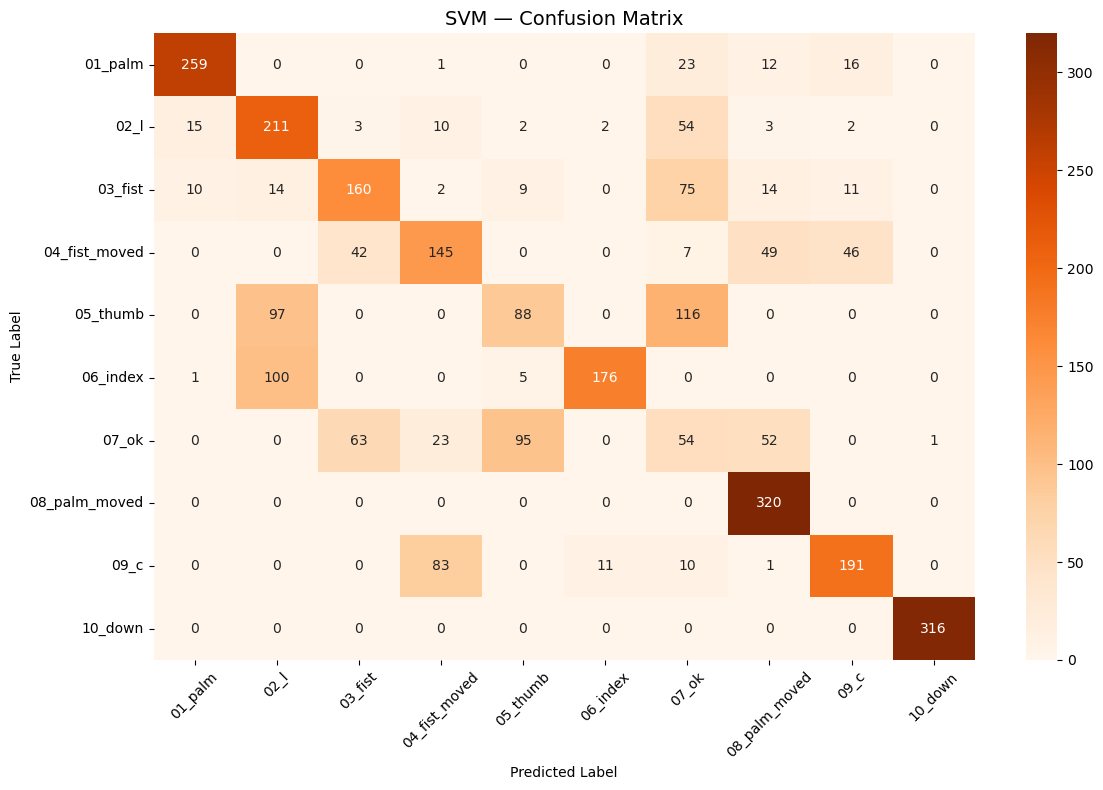

In [37]:
cm = confusion_matrix(y_test_svm, svm_test_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('SVM — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

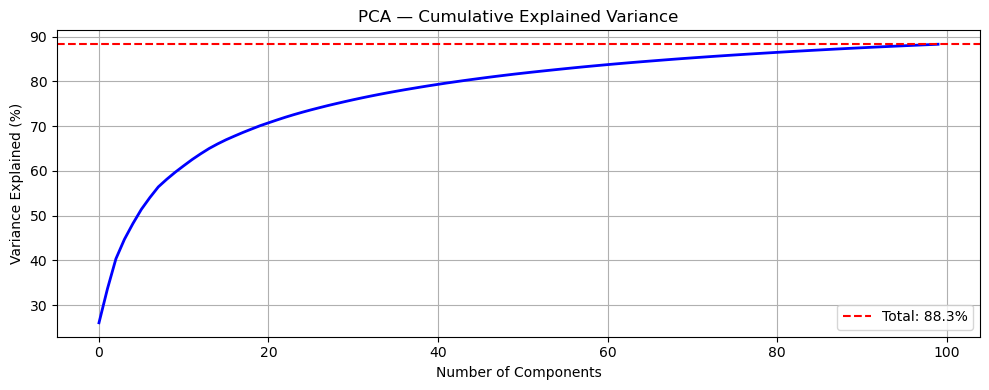

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_ * 100),
         color='blue', linewidth=2)
plt.axhline(y=explained, color='red',
            linestyle='--', label=f'Total: {explained:.1f}%')
plt.title('PCA — Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Third Model

In [39]:
!pip install torch torchvision

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {"GPU" if torch.cuda.is_available() else "CPU"}')

PyTorch version : 2.12.0
Device          : CPU


In [41]:
# CNN needs format: (samples, channels, height, width)
# From (samples, 64, 64, 1) → (samples, 1, 64, 64)

X_train_torch = torch.FloatTensor(X_train_aug.transpose(0, 3, 1, 2))
X_val_torch   = torch.FloatTensor(X_val.transpose(0, 3, 1, 2))
X_test_torch  = torch.FloatTensor(X_test.transpose(0, 3, 1, 2))

y_train_torch = torch.LongTensor(np.argmax(y_train_aug, axis=1))
y_val_torch   = torch.LongTensor(np.argmax(y_val, axis=1))
y_test_torch  = torch.LongTensor(np.argmax(y_test, axis=1))

train_loader = DataLoader(
    TensorDataset(X_train_torch, y_train_torch),
    batch_size=32, shuffle=True)
val_loader   = DataLoader(
    TensorDataset(X_val_torch, y_val_torch),
    batch_size=32, shuffle=False)
test_loader  = DataLoader(
    TensorDataset(X_test_torch, y_test_torch),
    batch_size=32, shuffle=False)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print('Data ready for CNN!')

Train batches : 875
Val batches   : 94
Test batches  : 94
Data ready for CNN!


In [42]:
# Based on research paper:
# Multiple Conv layers → Pooling → Fully Connected → Dropout → Output
# Paper uses CrossEntropy loss and Dropout for regularization

class GestureCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(GestureCNN, self).__init__()

        # Convolutional Block 1
        # Extracts basic edges and shapes
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),   # Stabilizes training
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 64x64 → 32x32
            nn.Dropout(0.25)      # Paper uses dropout
        )

        # Convolutional Block 2
        # Extracts complex patterns
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 32x32 → 16x16
            nn.Dropout(0.25)
        )

        # Convolutional Block 3
        # Extracts high level gesture features
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 16x16 → 8x8
            nn.Dropout(0.25)
        )

        # Fully Connected Layers
        # Makes final gesture classification
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),      # Paper uses 0.5 dropout
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)  # 10 gesture classes
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x

device    = torch.device('cpu')
cnn_model = GestureCNN(num_classes=10).to(device)

# Count parameters
total_params = sum(p.numel() for p in cnn_model.parameters())
print('CNN Model Built Successfully!')
print(f'Total Parameters : {total_params:,}')
print('\nArchitecture:')
print(cnn_model)

CNN Model Built Successfully!
Total Parameters : 4,421,834

Architecture:
GestureCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPoo

In [43]:
# Paper uses Cross Entropy Loss — exactly as stated
criterion = nn.CrossEntropyLoss()

# Adam optimizer — standard for CNN
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Reduce learning rate every 5 epochs
scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=5, gamma=0.5)

EPOCHS       = 15
train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []
best_val_acc = 0

print('Starting CNN Training...')
print('=' * 70)

for epoch in range(EPOCHS):

    # ── Training Phase ────────────────────────
    cnn_model.train()
    train_loss    = 0
    train_correct = 0
    train_total   = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs   = cnn_model(X_batch)

        # Cross Entropy Loss — as per research paper
        loss      = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        predicted      = outputs.argmax(dim=1)
        train_correct += (predicted == y_batch).sum().item()
        train_total   += y_batch.size(0)

    # ── Validation Phase ──────────────────────
    cnn_model.eval()
    val_loss    = 0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch     = X_batch.to(device)
            y_batch     = y_batch.to(device)
            outputs     = cnn_model(X_batch)
            loss        = criterion(outputs, y_batch)
            val_loss   += loss.item()
            predicted   = outputs.argmax(dim=1)
            val_correct += (predicted == y_batch).sum().item()
            val_total   += y_batch.size(0)

    # ── Calculate Metrics ─────────────────────
    t_acc  = train_correct / train_total * 100
    v_acc  = val_correct   / val_total   * 100
    t_loss = train_loss    / len(train_loader)
    v_loss = val_loss      / len(val_loader)

    train_accs.append(t_acc)
    val_accs.append(v_acc)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    # Save best model
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(cnn_model.state_dict(), 'best_cnn_model.pth')

    scheduler.step()

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
          f'Train Loss: {t_loss:.4f} | '
          f'Train Acc: {t_acc:.2f}% | '
          f'Val Loss: {v_loss:.4f} | '
          f'Val Acc: {v_acc:.2f}%')

print('=' * 70)
print(f'Training Complete!')
print(f'Best Validation Accuracy: {best_val_acc:.2f}%')

Starting CNN Training...
Epoch 01/15 | Train Loss: 0.6286 | Train Acc: 77.67% | Val Loss: 1.5501 | Val Acc: 67.00%
Epoch 02/15 | Train Loss: 0.1619 | Train Acc: 94.62% | Val Loss: 1.3563 | Val Acc: 75.47%
Epoch 03/15 | Train Loss: 0.1032 | Train Acc: 96.61% | Val Loss: 1.3716 | Val Acc: 78.87%
Epoch 04/15 | Train Loss: 0.0902 | Train Acc: 97.20% | Val Loss: 1.7594 | Val Acc: 81.20%
Epoch 05/15 | Train Loss: 0.0781 | Train Acc: 97.55% | Val Loss: 1.4292 | Val Acc: 77.33%
Epoch 06/15 | Train Loss: 0.0431 | Train Acc: 98.68% | Val Loss: 1.4256 | Val Acc: 80.77%
Epoch 07/15 | Train Loss: 0.0341 | Train Acc: 98.88% | Val Loss: 1.6124 | Val Acc: 79.70%
Epoch 08/15 | Train Loss: 0.0337 | Train Acc: 98.97% | Val Loss: 1.8972 | Val Acc: 76.27%
Epoch 09/15 | Train Loss: 0.0298 | Train Acc: 99.04% | Val Loss: 1.5825 | Val Acc: 80.73%
Epoch 10/15 | Train Loss: 0.0291 | Train Acc: 99.08% | Val Loss: 1.8347 | Val Acc: 77.43%
Epoch 11/15 | Train Loss: 0.0178 | Train Acc: 99.42% | Val Loss: 1.9560 | V

In [44]:
# Load best saved model for testing
cnn_model.load_state_dict(torch.load('best_cnn_model.pth'))
cnn_model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs   = cnn_model(X_batch.to(device))
        predicted = outputs.argmax(dim=1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

cnn_test_acc = accuracy_score(all_labels, all_preds)
total        = len(all_labels)
correct      = int(cnn_test_acc * total)

print('-' * 40)
print('        CNN — FINAL RESULTS')
print('-' * 40)
print(f'Best Val Accuracy : {best_val_acc:.2f}%')
print(f'Test Accuracy     : {cnn_test_acc * 100:.2f}%')
print(f'Total Tested      : {total}')
print(f'Correct           : {correct}')
print(f'Wrong             : {total - correct}')
print('-' * 40)

----------------------------------------
        CNN — FINAL RESULTS
----------------------------------------
Best Val Accuracy : 81.20%
Test Accuracy     : 82.70%
Total Tested      : 3000
Correct           : 2481
Wrong             : 519
----------------------------------------


In [45]:
print('CNN — Classification Report:\n')
print(classification_report(all_labels, all_preds,
                             target_names=le.classes_))

CNN — Classification Report:

               precision    recall  f1-score   support

      01_palm       0.66      0.94      0.78       311
         02_l       0.73      0.94      0.82       302
      03_fist       0.96      0.79      0.87       295
04_fist_moved       0.60      0.68      0.64       289
     05_thumb       1.00      0.84      0.91       301
     06_index       0.99      0.64      0.78       282
        07_ok       0.84      0.70      0.76       288
08_palm_moved       0.83      1.00      0.91       320
         09_c       0.95      0.69      0.80       296
      10_down       0.97      1.00      0.99       316

     accuracy                           0.83      3000
    macro avg       0.85      0.82      0.83      3000
 weighted avg       0.85      0.83      0.83      3000



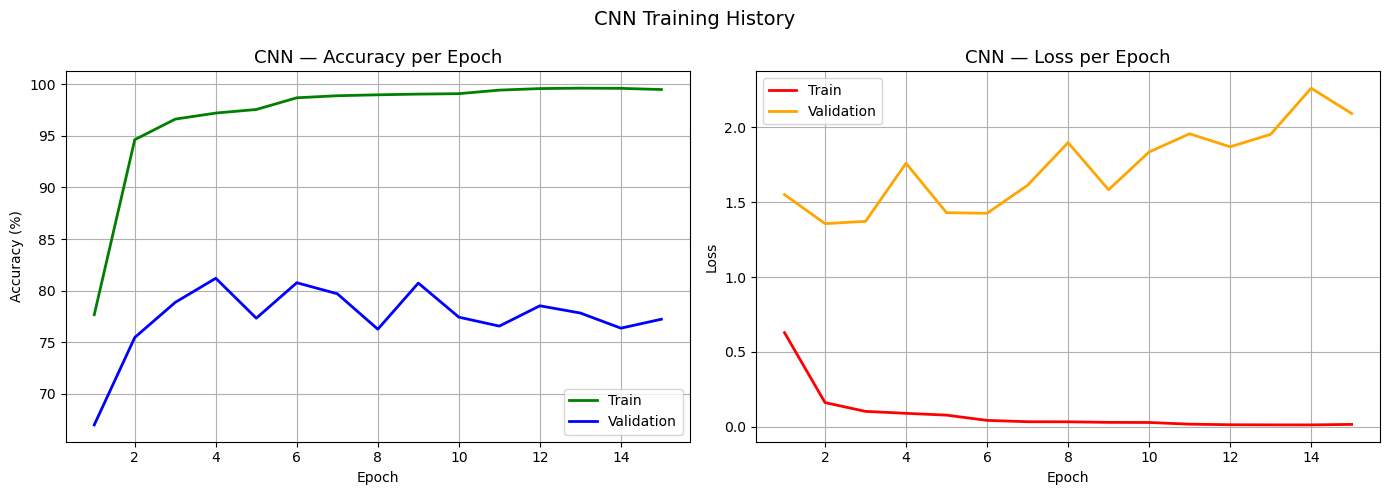

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(range(1, EPOCHS+1), train_accs,
             label='Train', color='green', linewidth=2)
axes[0].plot(range(1, EPOCHS+1), val_accs,
             label='Validation', color='blue', linewidth=2)
axes[0].set_title('CNN — Accuracy per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(range(1, EPOCHS+1), train_losses,
             label='Train', color='red', linewidth=2)
axes[1].plot(range(1, EPOCHS+1), val_losses,
             label='Validation', color='orange', linewidth=2)
axes[1].set_title('CNN — Loss per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('CNN Training History', fontsize=14)
plt.tight_layout()
plt.show()

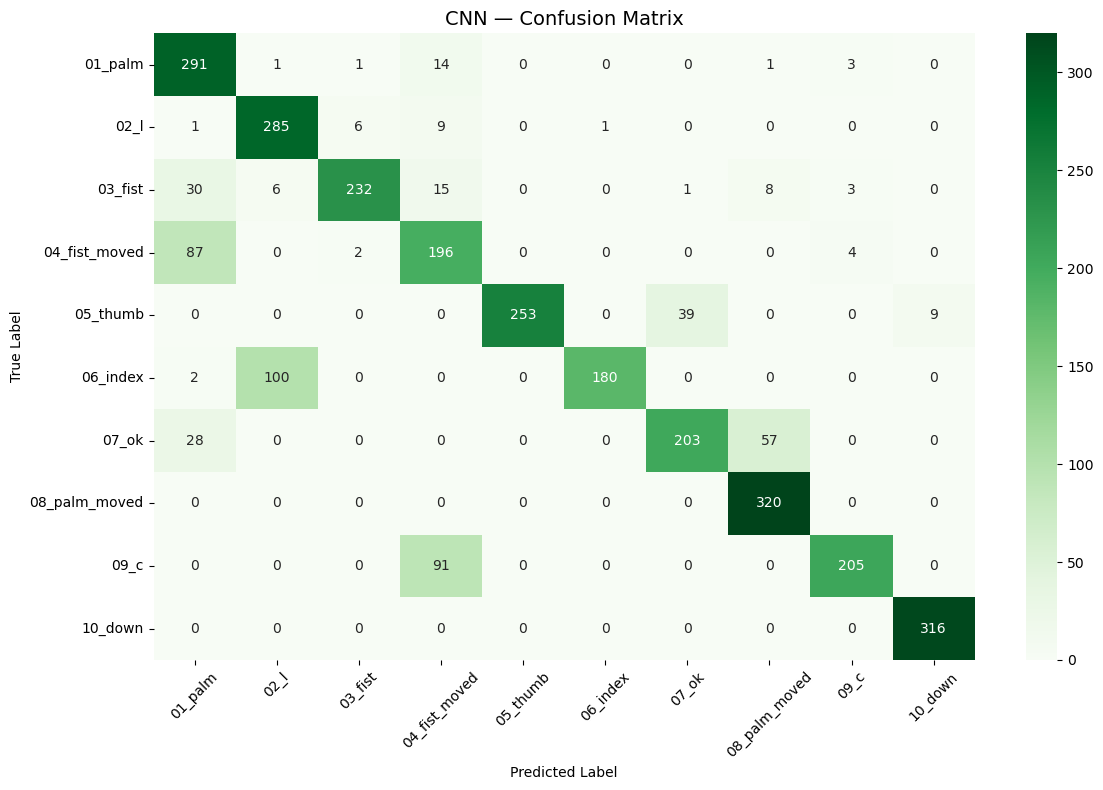

In [47]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('CNN — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Forth model 

In [49]:
class GestureCNNLSTM(nn.Module):
    def __init__(self, num_classes=10, sequence_length=16):
        super(GestureCNNLSTM, self).__init__()

        self.sequence_length = sequence_length

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        self.cnn_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512),  # increased from 256 → 512
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.lstm = nn.LSTM(
            input_size=512,       # increased from 256 → 512
            hidden_size=256,      # increased from 128 → 256
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True    # reads sequence both forward and backward
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 2, 128),  # *2 because bidirectional
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        cnn_out = self.cnn(x)
        cnn_out = self.cnn_fc(cnn_out)
        cnn_out = cnn_out.unsqueeze(1).repeat(
            1, self.sequence_length, 1)
        lstm_out, _ = self.lstm(cnn_out)
        out = lstm_out[:, -1, :]
        out = self.classifier(out)
        return out

device        = torch.device('cpu')
cnnlstm_model = GestureCNNLSTM(
    num_classes=10,
    sequence_length=16
).to(device)

total_params = sum(p.numel() for p in cnnlstm_model.parameters())
print('Improved CNN + LSTM Built!')
print(f'Total Parameters : {total_params:,}')

Improved CNN + LSTM Built!
Total Parameters : 7,508,810


In [50]:
# Cross Entropy Loss — as per research paper
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnnlstm_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(
    optimizer, step_size=5, gamma=0.5)

EPOCHS          = 25
train_losses_cl = []
val_losses_cl   = []
train_accs_cl   = []
val_accs_cl     = []
best_val_acc_cl = 0

print('Starting CNN + LSTM Training...')
print('=' * 70)

for epoch in range(EPOCHS):

    # ── Training Phase ────────────────────────
    cnnlstm_model.train()
    train_loss    = 0
    train_correct = 0
    train_total   = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs   = cnnlstm_model(X_batch)
        loss      = criterion(outputs, y_batch)
        loss.backward()

        # Gradient clipping — prevents exploding gradients in LSTM
        torch.nn.utils.clip_grad_norm_(
            cnnlstm_model.parameters(), max_norm=1.0)

        optimizer.step()

        train_loss    += loss.item()
        predicted      = outputs.argmax(dim=1)
        train_correct += (predicted == y_batch).sum().item()
        train_total   += y_batch.size(0)

    # ── Validation Phase ──────────────────────
    cnnlstm_model.eval()
    val_loss    = 0
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch     = X_batch.to(device)
            y_batch     = y_batch.to(device)
            outputs     = cnnlstm_model(X_batch)
            loss        = criterion(outputs, y_batch)
            val_loss   += loss.item()
            predicted   = outputs.argmax(dim=1)
            val_correct += (predicted == y_batch).sum().item()
            val_total   += y_batch.size(0)

    # ── Metrics ───────────────────────────────
    t_acc  = train_correct / train_total * 100
    v_acc  = val_correct   / val_total   * 100
    t_loss = train_loss    / len(train_loader)
    v_loss = val_loss      / len(val_loader)

    train_accs_cl.append(t_acc)
    val_accs_cl.append(v_acc)
    train_losses_cl.append(t_loss)
    val_losses_cl.append(v_loss)

    # Save best model
    if v_acc > best_val_acc_cl:
        best_val_acc_cl = v_acc
        torch.save(cnnlstm_model.state_dict(),
                   'best_cnnlstm_model.pth')

    scheduler.step()

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
          f'Train Loss: {t_loss:.4f} | '
          f'Train Acc: {t_acc:.2f}% | '
          f'Val Loss: {v_loss:.4f} | '
          f'Val Acc: {v_acc:.2f}%')

print('=' * 70)
print(f'Training Complete!')
print(f'Best Validation Accuracy : {best_val_acc_cl:.2f}%')

Starting CNN + LSTM Training...
Epoch 01/25 | Train Loss: 1.2354 | Train Acc: 52.18% | Val Loss: 1.3428 | Val Acc: 72.37%
Epoch 02/25 | Train Loss: 0.2274 | Train Acc: 93.25% | Val Loss: 0.8242 | Val Acc: 82.97%
Epoch 03/25 | Train Loss: 0.1131 | Train Acc: 96.92% | Val Loss: 1.2026 | Val Acc: 81.87%
Epoch 04/25 | Train Loss: 0.0829 | Train Acc: 97.91% | Val Loss: 1.3267 | Val Acc: 78.47%
Epoch 05/25 | Train Loss: 0.0590 | Train Acc: 98.47% | Val Loss: 1.5617 | Val Acc: 77.63%
Epoch 06/25 | Train Loss: 0.0330 | Train Acc: 99.15% | Val Loss: 2.0149 | Val Acc: 76.77%
Epoch 07/25 | Train Loss: 0.0245 | Train Acc: 99.37% | Val Loss: 1.7810 | Val Acc: 78.33%
Epoch 08/25 | Train Loss: 0.0223 | Train Acc: 99.49% | Val Loss: 1.7172 | Val Acc: 81.77%
Epoch 09/25 | Train Loss: 0.0253 | Train Acc: 99.45% | Val Loss: 1.6058 | Val Acc: 77.63%
Epoch 10/25 | Train Loss: 0.0213 | Train Acc: 99.50% | Val Loss: 1.5887 | Val Acc: 81.73%
Epoch 11/25 | Train Loss: 0.0146 | Train Acc: 99.64% | Val Loss: 1.6

In [51]:
# Load best saved model
cnnlstm_model.load_state_dict(
    torch.load('best_cnnlstm_model.pth'))
cnnlstm_model.eval()

all_preds_cl  = []
all_labels_cl = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs   = cnnlstm_model(X_batch.to(device))
        predicted = outputs.argmax(dim=1)
        all_preds_cl.extend(predicted.cpu().numpy())
        all_labels_cl.extend(y_batch.numpy())

cnnlstm_test_acc = accuracy_score(all_labels_cl, all_preds_cl)
total            = len(all_labels_cl)
correct          = int(cnnlstm_test_acc * total)

print('-' * 40)
print('     CNN + LSTM — FINAL RESULTS')
print('-' * 40)
print(f'Best Val Accuracy : {best_val_acc_cl:.2f}%')
print(f'Test Accuracy     : {cnnlstm_test_acc * 100:.2f}%')
print(f'Total Tested      : {total}')
print(f'Correct           : {correct}')
print(f'Wrong             : {total - correct}')
print('-' * 40)

----------------------------------------
     CNN + LSTM — FINAL RESULTS
----------------------------------------
Best Val Accuracy : 84.40%
Test Accuracy     : 86.40%
Total Tested      : 3000
Correct           : 2592
Wrong             : 408
----------------------------------------


In [52]:
print('CNN + LSTM — Classification Report:\n')
print(classification_report(all_labels_cl, all_preds_cl,
                             target_names=le.classes_))

CNN + LSTM — Classification Report:

               precision    recall  f1-score   support

      01_palm       0.94      0.92      0.93       311
         02_l       0.91      0.94      0.93       302
      03_fist       0.93      0.82      0.87       295
04_fist_moved       0.85      0.67      0.75       289
     05_thumb       0.99      0.92      0.96       301
     06_index       0.75      0.94      0.83       282
        07_ok       0.96      0.48      0.64       288
08_palm_moved       0.85      1.00      0.92       320
         09_c       0.67      0.91      0.77       296
      10_down       0.93      1.00      0.96       316

     accuracy                           0.86      3000
    macro avg       0.88      0.86      0.86      3000
 weighted avg       0.88      0.86      0.86      3000



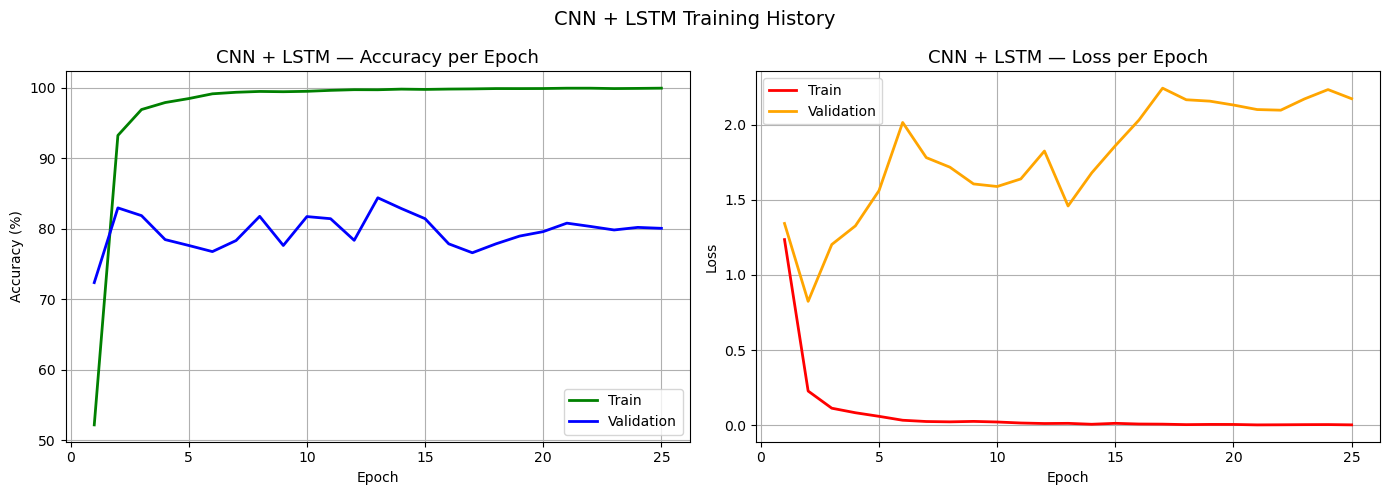

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(range(1, EPOCHS+1), train_accs_cl,
             label='Train', color='green', linewidth=2)
axes[0].plot(range(1, EPOCHS+1), val_accs_cl,
             label='Validation', color='blue', linewidth=2)
axes[0].set_title('CNN + LSTM — Accuracy per Epoch', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(range(1, EPOCHS+1), train_losses_cl,
             label='Train', color='red', linewidth=2)
axes[1].plot(range(1, EPOCHS+1), val_losses_cl,
             label='Validation', color='orange', linewidth=2)
axes[1].set_title('CNN + LSTM — Loss per Epoch', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('CNN + LSTM Training History', fontsize=14)
plt.tight_layout()
plt.show()

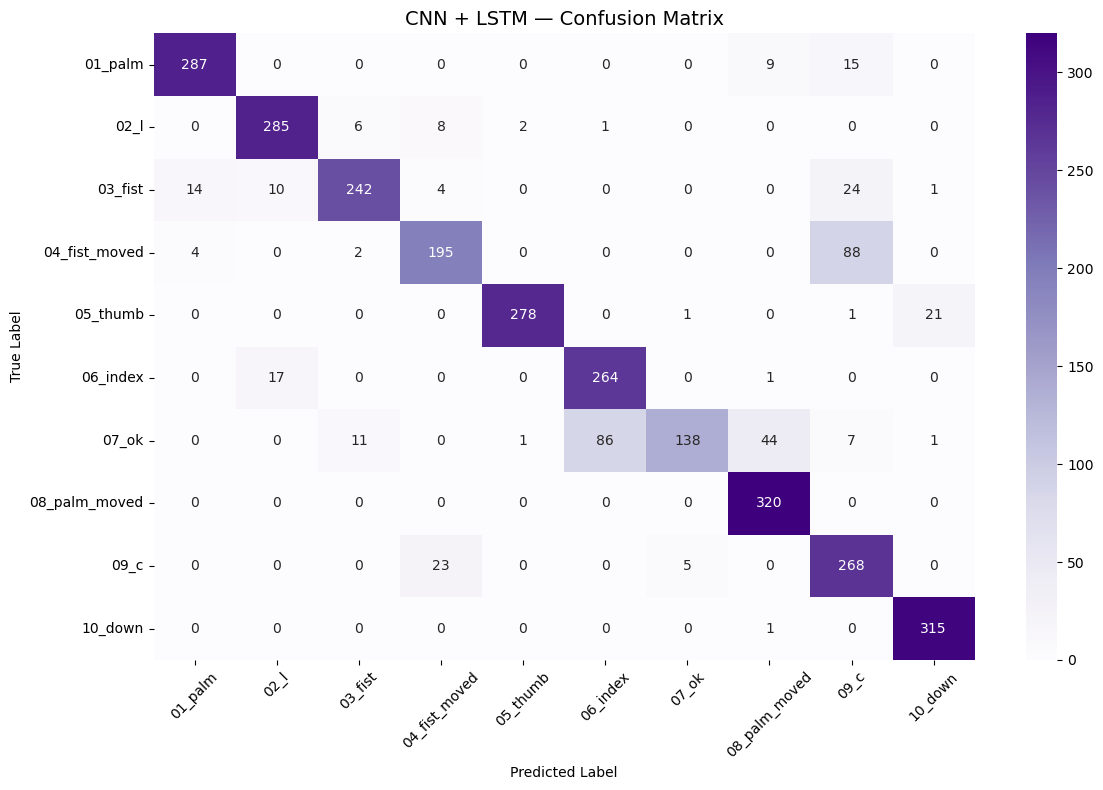

In [54]:
cm = confusion_matrix(all_labels_cl, all_preds_cl)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('CNN + LSTM — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

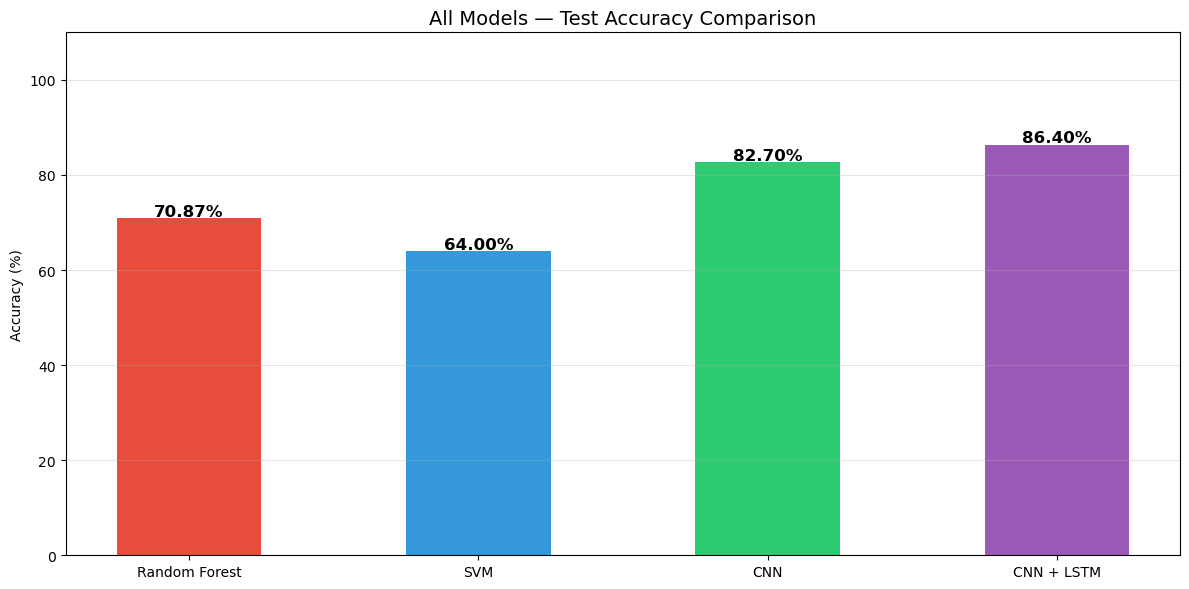


--------------------------------------------------
        FINAL PROJECT SUMMARY
--------------------------------------------------
Random Forest : 70.87%  — Classical ML
SVM           : 64.00%  — Classical ML
CNN           : 82.70%  — Deep Learning
CNN + LSTM    : 86.40%  — Advanced DL
--------------------------------------------------

 BEST MODEL : CNN + LSTM — 86.40%


In [56]:
models    = ['Random Forest', 'SVM', 'CNN', 'CNN + LSTM']
test_accs = [
    rf_test_acc      * 100,
    svm_test_acc     * 100,
    cnn_test_acc     * 100,
    cnnlstm_test_acc * 100
]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

plt.figure(figsize=(12, 6))
bars = plt.bar(models, test_accs, color=colors, width=0.5)

for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center',
             fontsize=12, fontweight='bold')

plt.title('All Models — Test Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\n' + '-' * 50)
print('        FINAL PROJECT SUMMARY')
print('-' * 50)
print(f'Random Forest : {rf_test_acc      * 100:.2f}%  — Classical ML')
print(f'SVM           : {svm_test_acc     * 100:.2f}%  — Classical ML')
print(f'CNN           : {cnn_test_acc     * 100:.2f}%  — Deep Learning')
print(f'CNN + LSTM    : {cnnlstm_test_acc * 100:.2f}%  — Advanced DL')
print('-' * 50)
print(f'\n BEST MODEL : CNN + LSTM — {cnnlstm_test_acc * 100:.2f}%') 